In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
from astropy.io import fits
from astropy.table import Table

In [2]:
candels_cat_file = '../catalog/gds.fits'
other_candels_cat_file = '../catalog/hlsp_candels_hst_wfc3_goodss-tot-multiband_f160w_v1_cat.fits'

jwst_files = glob.glob("../data/hlsp_*")
nisp_files = glob.glob("../data/NISP_HUDF/*")

In [3]:
def match_catalog(file_name, gal_coords, hdu=0, url=None, dbx=None):
    if url is None: # get images locally
        with fits.open(file_name) as hdul:
            image_header = hdul[hdu].header
            image_data = hdul[hdu].data
    else: # Get FITS file from dropbox
        image_header, image_data = get_fits_file(url, file_name, dbx=dbx)
    
    wcs = WCS(image_header)
    
    return np.where(gal_coords.contained_by(wcs))[0]

In [32]:
tbl = Table.read(candels_cat_file).to_pandas()
tbl['ACS_F814W_MAG'] = 23.9-2.5*np.log10(tbl.ACS_F814W_FLUX)
tbl = tbl[
        (tbl.z_best > 0.01) & (tbl.z_best < 3.0)
        & (tbl.ACS_F814W_MAG < 25)
        & (tbl.FLUX_RADIUS_2_F814W < 30) & (tbl.FLUX_RADIUS_2_F814W > 3) # Can be flexible with this (remove or make much larger)
        & (tbl.CLASS_STAR < 0.05)
]
len(tbl)

/home/eaev/superNISP/.superNISP/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


5815

In [112]:
gal_coords = SkyCoord(ra=tbl.RAdeg, dec=tbl.DECdeg, unit='deg')

In [119]:
with fits.open(jwst_files[0]) as hdul:
    print(hdul.info())
    jwst_hdr = hdul[1].header
    wcs = WCS(hdul[1].header)
    jwst_data = hdul[1].data
print(wcs)
gal_coords = gal_coords[np.where(gal_coords.contained_by(wcs))[0]]

Filename: ../data/hlsp_jades_jwst_nircam_goods-s-deep_f115w_v2.0_drz_shooby.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     442   ()      
  1  SCI           1 ImageHDU        83   (25000, 27700)   float32   
  2  ERR           1 ImageHDU        83   (25000, 27700)   float32   
  3  EXP           1 ImageHDU        83   (25000, 27700)   float32   
  4  WHT           1 ImageHDU        83   (25000, 27700)   float32   
None
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 53.12278110761878 -27.80516045555555 
CRPIX : 11924.5 16791.5 
PC1_1 PC1_2  : -1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : 8.3318730000584e-06 8.3318730000584e-06 
NAXIS : 25000  27700


Set DATE-AVG to '2022-10-08T02:26:24.819' from MJD-AVG.
Set DATE-END to '2022-10-09T02:34:11.369' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    22.090597 from OBSGEO-[XYZ].
Set OBSGEO-H to 1234812278.786 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [120]:
len(gal_coords), gal_coords[0]

(4847,
 <SkyCoord (ICRS): (ra, dec) in deg
     (53.0781479, -27.9446793)>)

In [121]:
x, y = wcs.world_to_pixel(gal_coords)

In [122]:
crpix = 11924.5, 16791.5
center = wcs.pixel_to_world(11924.5, 16791.5)
print(center.contained_by(wcs))

True


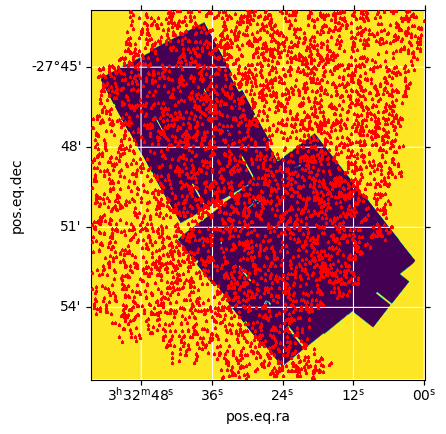

In [123]:
c = 13000
ax = plt.subplot(projection=wcs) 
ax.imshow(jwst_data, origin='lower')
zero_data = jwst_data.copy()
zero_data[np.where(zero_data==0)] = 1000
ax.imshow(zero_data, origin='lower')

plt.plot(x, y, 'r*', ms=2)
Nx, Ny = jwst_data.shape
# ax.plot(Ny/2, Nx/2, 'r*')
# ax.plot(crpix[1], crpix[0], 'b*')
ax.grid(color='white', ls='solid')
plt.show()

In [127]:
clips = []
size=66
for coord in gal_coords:
    clip = Cutout2D(jwst_data, coord, size=size, wcs=wcs, mode='trim')
    if sum(clip.data.shape) != size*2: continue
    frac_zero = np.sum((clip.data==0.0).astype(int))/(size**2)
    if frac_zero < 0.5:
        clips.append(clip)
len(clips)

2057

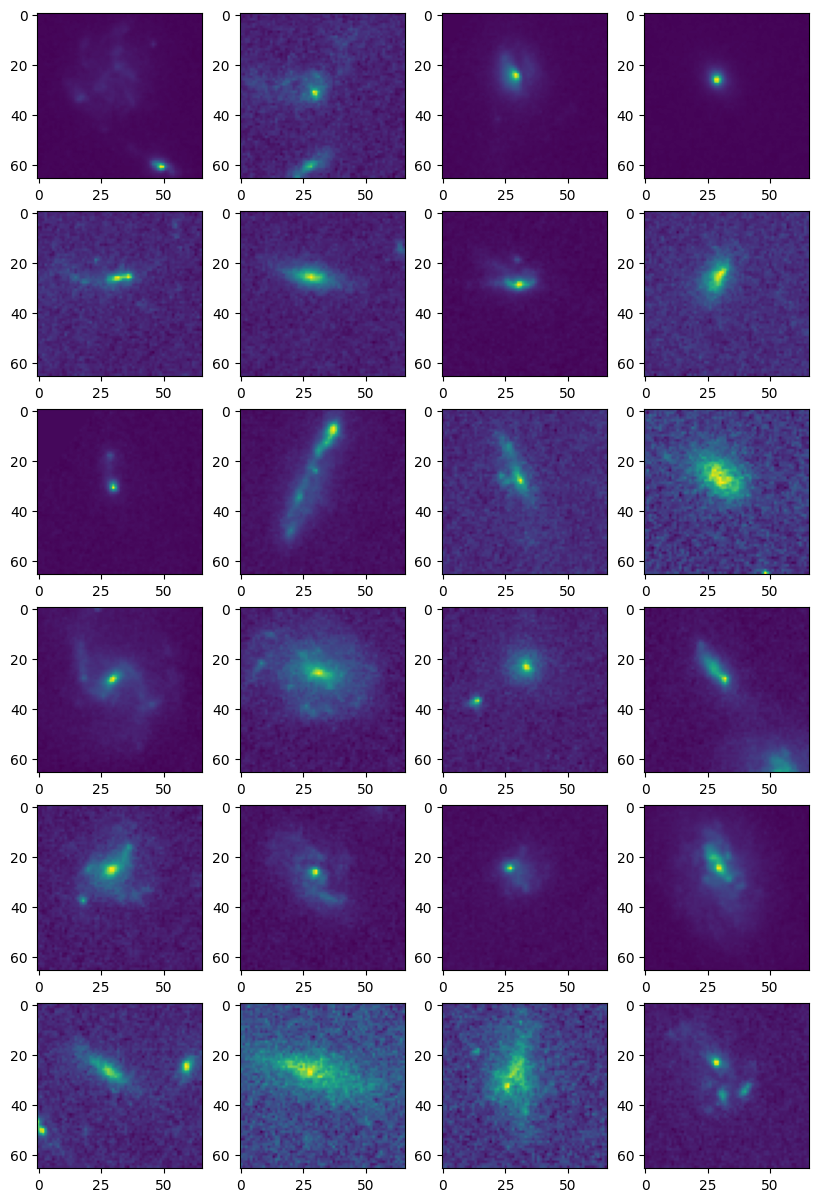

In [128]:
fig, axes = plt.subplots(6, 4, figsize=(10, 15))
for i in range(6*4):
    axes.flatten()[i].imshow(clips[i].data)

In [ ]:
# # Plotting images for verification purposes
# n_rows = 6
# fig, axes = plt.subplots(n_rows, 4, figsize=(10,2.5*n_rows))
# for i in range(n_rows*2):
#     clip_jwst = jwst_cutouts[i]
#     clip_nisp = nisp_cutouts[i]
#     axes.flatten()[i*2].imshow(clip_jwst)
#     axes.flatten()[i*2+1].imshow(clip_nisp)
# plt.savefig("../plots/euclid_nisp_matches.png", bbox_inches='tight')